# 1. Set up

This notebook trains a DCNN (AlexNet) for emotion recognition and can be run in two different data styles:
- original EMO-DB: one emotion per utterance, so you can keep segment-level and utterance-level reporting
- combined EMO-DB: one utterance may contain multiple emotions, so report only segment-level results

It also supports two label styles for combined data:
- hard: one class index per segment
- soft: a 7-value probability vector per segment, usually used when a segment overlaps a transition

Recommended run order:
1. Set DATASET, DATA_KIND, SPLIT_MODE, and LABEL_MODE in the config cell
2. Run the setup and training cells in order
3. For original data, run the utterance-level report cells as well
4. For combined data, use the segment-level report only; the utterance-level section is skipped

For soft labels, the notebook reports single-emotion segments with a normal confusion matrix and classification report, then summarizes two-emotion transition segments by pair (ordered pair metadata from y_pair_*.npy) using pair accuracy and soft-vector error metrics.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import os

# set seed
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
CURR_DIR = os.getcwd() 

# ================================================================
# Choose your dataset, data kind, label mode, and split mode
# ================================================================

DATASET = "processed_emodb_comb_norm_loso_soft"
DATA_KIND = "combined"  # "original" or "combined"
LABEL_MODE = "soft"  # "hard" or "soft"; soft mode uses y_soft_*.npy when available
NUM_CLASSES = 7

# SPLIT_MODE = "original"   # "original" or "loso"
SPLIT_MODE = "loso"

# ================================================================

DATASET_PATH = os.path.join(CURR_DIR, DATASET)

MODEL_DIR = os.path.join(CURR_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DCNN_NAME = f"dcnn_{DATASET}.pth"
SVM_NAME = f"svm_{DATASET}.joblib"

DCNN_PATH = os.path.join(MODEL_DIR, DCNN_NAME)

RESULTS_DIR = os.path.join(CURR_DIR, "results", DATASET)
os.makedirs(RESULTS_DIR, exist_ok=True)

if SPLIT_MODE == "loso":
    FOLD_NAMES = sorted([
        name for name in os.listdir(DATASET_PATH)
        if name.startswith("fold") and os.path.isdir(os.path.join(DATASET_PATH, name))
    ])
    if len(FOLD_NAMES) == 0:
        raise ValueError(f"No fold directories found under {DATASET_PATH}. Expected fold1..fold10")
else:
    FOLD_NAMES = []

print(f"Using dataset at          : {DATASET_PATH}")
print(f"Data kind                 : {DATA_KIND}")
print(f"Split mode                : {SPLIT_MODE}")
print(f"Label mode                : {LABEL_MODE}")
print(f"Num classes               : {NUM_CLASSES}")
if SPLIT_MODE == "loso":
    print(f"Detected folds             : {FOLD_NAMES}")
print(f"DCNN model path (original) : {DCNN_PATH}")
print(f"Results will be saved to   : {RESULTS_DIR}")

Using dataset at          : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/processed_emodb_comb_norm_loso_soft
Data kind                 : combined
Split mode                : loso
Label mode                : soft
Num classes               : 7
Detected folds             : ['fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9']
DCNN model path (original) : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_comb_norm_loso_soft.pth
Results will be saved to   : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso_soft


# 2. Train DCNN

In this section, we fine-tune AlexNet on 3-channel log-Mel segment images (log-Mel, delta, delta-delta).

This notebook supports two modes:
- original: train and evaluate using one fixed train/validation/test split
- loso: run 10 folds (one test speaker per fold), then collate all test-fold predictions into one final result

It also supports two label formats for Section 2:
- hard labels: one class index per segment, using y_train.npy / y_validation.npy / y_test.npy
- soft labels: a 7-value probability vector per segment, using y_soft_train.npy / y_soft_validation.npy / y_soft_test.npy

Recommended run order for Section 2:
1. Set DATASET, SPLIT_MODE, and LABEL_MODE in Cell 3
2. Run Cells 6 to 12 in order
3. Check saved artifacts in the dataset-specific results folder

In [3]:
# Transform for image preprocessing
# ToTensor: Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0].
# Resize: Resizes the input image to the given size. Here we resize to (227, 227) which is the input size for AlexNet.
# Normalize: Normalizes a tensor image with mean and standard deviation. The mean and std are calculated from the ImageNet dataset, which is commonly used for pre-trained models.
transform = transforms.Compose([
            transforms.ToTensor(),                          
            transforms.Resize((227, 227), antialias=True),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

In [4]:
class MelSegmentDataset(Dataset):
    """Dataset for loading mel-spectrogram segments and hard or soft labels from .npy files."""
    def __init__(self, x_path, y_path, y_soft_path=None, y_pair_path=None, label_mode="hard"):
        self.X = np.load(x_path)
        self.y = np.load(y_path)
        self.transform = transform
        self.label_mode = label_mode
        self.y_soft = None
        self.y_pair = None

        if self.label_mode == "soft":
            soft_path = y_soft_path if y_soft_path is not None else y_path.replace("y_", "y_soft_")
            if os.path.exists(soft_path):
                self.y_soft = np.load(soft_path)
            else:
                print(f"[WARN] Soft labels requested but not found at {soft_path}; falling back to hard labels.")
                self.label_mode = "hard"

            # Pair metadata is optional: keep soft-label training even when pair files are absent.
            if self.label_mode == "soft":
                pair_path = y_pair_path if y_pair_path is not None else y_path.replace("y_", "y_pair_")
                if os.path.exists(pair_path):
                    self.y_pair = np.load(pair_path)
                else:
                    print(f"[WARN] Pair metadata not found at {pair_path}; continuing without y_pair metadata.")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 1) Read one (3, 64, 64) feature tensor
        img = self.X[idx].copy()

        # 2) Min-max scale each channel independently to [0, 1]
        for c in range(3):
            min_val = img[c].min()
            max_val = img[c].max()
            if max_val > min_val:
                img[c] = (img[c] - min_val) / (max_val - min_val)
            else:
                img[c] = 0.0

        # 3) Convert (C, H, W) -> (H, W, C) for torchvision transforms
        img = img.transpose(1, 2, 0)

        # 4) Apply resize + ImageNet normalization
        if self.label_mode == "soft" and self.y_soft is not None:
            target = torch.tensor(self.y_soft[idx], dtype=torch.float32)
        else:
            target = torch.tensor(self.y[idx], dtype=torch.long)
        return self.transform(img).float(), target

def build_dataloaders(dataset_dir, batch_size=32, label_mode=LABEL_MODE):
    train_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_train.npy"),
        os.path.join(dataset_dir, "y_train.npy"),
        y_soft_path=os.path.join(dataset_dir, "y_soft_train.npy"),
        y_pair_path=os.path.join(dataset_dir, "y_pair_train.npy"),
        label_mode=label_mode
    )
    validation_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_validation.npy"),
        os.path.join(dataset_dir, "y_validation.npy"),
        y_soft_path=os.path.join(dataset_dir, "y_soft_validation.npy"),
        y_pair_path=os.path.join(dataset_dir, "y_pair_validation.npy"),
        label_mode=label_mode
    )
    test_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_test.npy"),
        os.path.join(dataset_dir, "y_test.npy"),
        y_soft_path=os.path.join(dataset_dir, "y_soft_test.npy"),
        y_pair_path=os.path.join(dataset_dir, "y_pair_test.npy"),
        label_mode=label_mode
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, validation_loader, test_loader

# Keep original behavior for non-LOSO mode
if SPLIT_MODE == "original":
    train_loader, validation_loader, test_loader = build_dataloaders(DATASET_PATH, batch_size=32, label_mode=LABEL_MODE)
else:
    print("LOSO mode: dataloaders are built fold-by-fold in the training cell.")

LOSO mode: dataloaders are built fold-by-fold in the training cell.


In [5]:
def create_dcnn_model(device):
    # Initialize pre-trained AlexNet
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    # Replace the classifier head for 7 emotion classes
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 7)
    return model.to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if SPLIT_MODE == "original":
    model = create_dcnn_model(device)
else:
    print("LOSO mode: model will be initialized inside each fold loop.")

LOSO mode: model will be initialized inside each fold loop.


In [6]:
def soft_target_cross_entropy(logits, soft_targets):
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

def labels_to_hard_indices(labels):
    if labels.ndim > 1:
        return torch.argmax(labels, dim=1)
    return labels

def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        if labels.ndim > 1:
            loss = soft_target_cross_entropy(outputs, labels.float())
        else:
            loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if labels.ndim > 1:
                loss = soft_target_cross_entropy(outputs, labels.float())
            else:
                loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            hard_labels = labels_to_hard_indices(labels)
            total += hard_labels.size(0)
            correct += (predicted == hard_labels).sum().item()
    accuracy = correct / total
    return running_loss / len(dataloader), accuracy


# Capture all training prints so they can be saved into the report file
dcnn_training_logs = []
def log_dcnn(message):
    print(message)
    dcnn_training_logs.append(str(message))

In [7]:
from sklearn.metrics import accuracy_score

# Training setup (SGD, lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()
PATIENCE = 5

def majority_vote(labels):
    # If multiple labels have equal max count, pick one arbitrarily (dictionary order).
    counts = {}
    for lb in labels:
        counts[int(lb)] = counts.get(int(lb), 0) + 1
    return max(counts, key=counts.get)

# Reuse training logs list from Cell 9 if available; otherwise create it.
if 'dcnn_training_logs' not in globals():
    dcnn_training_logs = []

def log_dcnn(message):
    print(message)
    dcnn_training_logs.append(str(message))

def collect_segment_outputs(model, dataloader):
    """Return hard/soft labels, predicted probabilities, and transition metadata for one loader."""
    model.eval()
    pred_hard_all = []
    pred_prob_all = []
    true_hard_all = []
    true_soft_all = []
    active_count_all = []
    pair_all = []
    cursor = 0
    dataset = dataloader.dataset
    with torch.no_grad():
        for inputs, labels in dataloader:
            batch_size = labels.shape[0]
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1).astype(np.int64)
            labels_np = labels.cpu().numpy()
            if labels_np.ndim == 1:
                true_hard = labels_np.astype(np.int64)
                true_soft = np.eye(NUM_CLASSES, dtype=np.float32)[true_hard]
            else:
                true_soft = labels_np.astype(np.float32)
                true_hard = np.argmax(true_soft, axis=1).astype(np.int64)

            if getattr(dataset, 'y_pair', None) is not None:
                pair_batch = np.array(dataset.y_pair[cursor:cursor + batch_size], dtype=np.int64)
            else:
                pair_batch = np.full((batch_size, 2), fill_value=-1, dtype=np.int64)

            pred_hard_all.extend(preds.tolist())
            pred_prob_all.extend(probs.tolist())
            true_hard_all.extend(true_hard.tolist())
            true_soft_all.extend(true_soft.tolist())
            active_count_all.extend((true_soft > 1e-8).sum(axis=1).astype(np.int64).tolist())
            pair_all.extend(pair_batch.tolist())
            cursor += batch_size

    return {
        'pred_hard': np.array(pred_hard_all, dtype=np.int64),
        'pred_prob': np.array(pred_prob_all, dtype=np.float32),
        'true_hard': np.array(true_hard_all, dtype=np.int64),
        'true_soft': np.array(true_soft_all, dtype=np.float32),
        'active_count': np.array(active_count_all, dtype=np.int64),
        'pair': np.array(pair_all, dtype=np.int64),
    }

def train_dcnn_one_run(model, train_loader, validation_loader, save_path, max_epochs=50):
    """Train one DCNN model with early stopping on validation loss."""
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = evaluate(model, validation_loader, criterion)

        log_dcnn(
            f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            log_dcnn(f"Validation loss improved, model saved to: {save_path}")
        else:
            counter += 1
            log_dcnn(f"Validation loss did not improve. Counter: {counter}/{PATIENCE}")
            if counter >= PATIENCE:
                log_dcnn("Validation loss increased, stopping early.")
                break

# Global evaluation pools for the final report.
segment_pred_hard_all = []
segment_pred_prob_all = []
segment_true_hard_all = []
segment_true_soft_all = []
segment_active_count_all = []
segment_pair_all = []

if SPLIT_MODE == "original":
    train_dcnn_one_run(model, train_loader, validation_loader, DCNN_PATH, max_epochs=50)
    eval_out = collect_segment_outputs(model, test_loader)
    segment_pred_hard_all = eval_out['pred_hard'].tolist()
    segment_pred_prob_all = eval_out['pred_prob'].tolist()
    segment_true_hard_all = eval_out['true_hard'].tolist()
    segment_true_soft_all = eval_out['true_soft'].tolist()
    segment_active_count_all = eval_out['active_count'].tolist()
    segment_pair_all = eval_out['pair'].tolist()
    y_true_cv = eval_out['true_hard']
    y_pred_cv = eval_out['pred_hard']

else:
    all_y_true_utt = []
    all_y_pred_utt = []
    cv_fold_summaries = []

    for fold_name in FOLD_NAMES:
        log_dcnn("=" * 70)
        log_dcnn(f"Running fold: {fold_name}")
        fold_path = os.path.join(DATASET_PATH, fold_name)
        fold_train_loader, fold_validation_loader, fold_test_loader = build_dataloaders(fold_path, batch_size=32, label_mode=LABEL_MODE)

        fold_model = create_dcnn_model(device)
        fold_model_path = os.path.join(MODEL_DIR, f"dcnn_{DATASET}_{fold_name}.pth")
        train_dcnn_one_run(
            fold_model,
            fold_train_loader,
            fold_validation_loader,
            fold_model_path,
            max_epochs=50,
        )

        fold_model.load_state_dict(torch.load(fold_model_path, map_location=device))
        eval_out = collect_segment_outputs(fold_model, fold_test_loader)

        segment_pred_hard_all.extend(eval_out['pred_hard'].tolist())
        segment_pred_prob_all.extend(eval_out['pred_prob'].tolist())
        segment_true_hard_all.extend(eval_out['true_hard'].tolist())
        segment_true_soft_all.extend(eval_out['true_soft'].tolist())
        segment_active_count_all.extend(eval_out['active_count'].tolist())
        segment_pair_all.extend(eval_out['pair'].tolist())

        u_ids_test = np.load(os.path.join(fold_path, "utterance_ids_test.npy"))
        if not (len(u_ids_test) == len(eval_out['pred_hard']) == len(eval_out['true_hard'])):
            raise ValueError(
                f"Length mismatch in {fold_name}: utterance_ids={len(u_ids_test)}, "
                f"preds={len(eval_out['pred_hard'])}, labels={len(eval_out['true_hard'])}"
            )

        utt_pred_buckets = {}
        utt_true_label = {}
        for uid, pred, true_label in zip(u_ids_test, eval_out['pred_hard'], eval_out['true_hard']):
            if uid not in utt_pred_buckets:
                utt_pred_buckets[uid] = []
                utt_true_label[uid] = true_label
            utt_pred_buckets[uid].append(pred)

        y_true_utt_fold = []
        y_pred_utt_fold = []
        for uid, pred_list in utt_pred_buckets.items():
            y_true_utt_fold.append(utt_true_label[uid])
            y_pred_utt_fold.append(majority_vote(pred_list))

        y_true_utt_fold = np.array(y_true_utt_fold)
        y_pred_utt_fold = np.array(y_pred_utt_fold)
        fold_utt_acc = accuracy_score(y_true_utt_fold, y_pred_utt_fold)
        cv_fold_summaries.append((fold_name, fold_utt_acc, len(y_true_utt_fold)))
        log_dcnn(
            f"Fold {fold_name} utterance-level accuracy: {fold_utt_acc * 100:.2f}% "
            f"({len(y_true_utt_fold)} utterances)"
        )

        all_y_true_utt.extend(y_true_utt_fold.tolist())
        all_y_pred_utt.extend(y_pred_utt_fold.tolist())

    y_true_cv = np.array(all_y_true_utt)
    y_pred_cv = np.array(all_y_pred_utt)
    cv_utt_acc = accuracy_score(y_true_cv, y_pred_cv)
    log_dcnn("=" * 70)
    log_dcnn(f"LOSO combined utterance-level accuracy: {cv_utt_acc * 100:.2f}%")
    for fold_name, fold_acc, utt_count in cv_fold_summaries:
        log_dcnn(f"  {fold_name}: {fold_acc * 100:.2f}% on {utt_count} utterances")

Running fold: fold1
Epoch 1, Train Loss: 1.1821, Val Loss: 1.1999, Val Accuracy: 0.5451
Validation loss improved, model saved to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_comb_norm_loso_soft_fold1.pth
Epoch 2, Train Loss: 0.7784, Val Loss: 1.4668, Val Accuracy: 0.5264
Validation loss did not improve. Counter: 1/5
Epoch 3, Train Loss: 0.6040, Val Loss: 1.1892, Val Accuracy: 0.6024
Validation loss improved, model saved to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_comb_norm_loso_soft_fold1.pth
Epoch 4, Train Loss: 0.4797, Val Loss: 1.5835, Val Accuracy: 0.5700
Validation loss did not improve. Counter: 1/5
Epoch 5, Train Loss: 0.3802, Val Loss: 1.6584, Val Accuracy: 0.5260
Validation loss did not improve. Counter: 2/5
Epoch 6, Train Loss: 0.3188, Val Loss: 1.9406, Val Accuracy: 0.5000
Validation loss did not improve. Counter: 3/5
Epoch 7, Train Loss: 0.2748, Val Loss: 1.6

In [8]:
# Evaluate DCNN on test set in original mode; LOSO mode was already evaluated fold-by-fold above
if SPLIT_MODE == "original":
    model.load_state_dict(torch.load(DCNN_PATH, map_location=device))
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    test_summary = f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}"
    print(test_summary)

    if 'dcnn_training_logs' in globals():
        dcnn_training_logs.append(test_summary.strip())
else:
    print("LOSO mode: skipped single test-set evaluation (already evaluated per fold).")

LOSO mode: skipped single test-set evaluation (already evaluated per fold).


Final global segment accuracy (combined, loso): 59.14%

Section A. Segment-level classification for single-emotion segments only:
              precision    recall  f1-score   support

       Anger     0.6766    0.7986    0.7326      3207
     Boredom     0.5077    0.4986    0.5031      2120
        Fear     0.5759    0.4202    0.4859      1561
   Happiness     0.4539    0.3865    0.4175      1656
     Sadness     0.8013    0.8430    0.8216      2669
     Disgust     0.4839    0.4481    0.4653      1377
     Neutral     0.5362    0.5626    0.5491      1854

    accuracy                         0.6109     14444
   macro avg     0.5765    0.5654    0.5679     14444
weighted avg     0.6021    0.6109    0.6035     14444

Dataset: processed_emodb_comb_norm_loso_soft
Data kind: combined
Split mode: loso
Label mode: soft
All segment accuracy: 59.14%

Section A. Single-emotion segment classification:
              precision    recall  f1-score   support

       Anger     0.6766    0.7986    0.

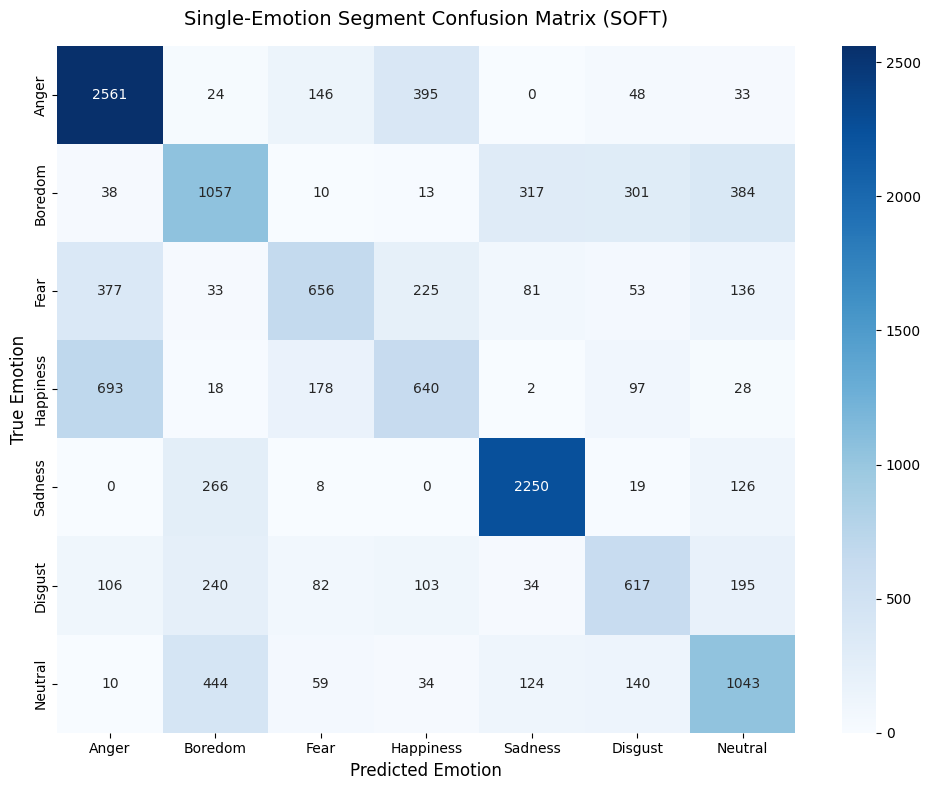

Saved confusion matrix figure to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso_soft/confusion_dcnn_processed_emodb_comb_norm_loso_soft.png


In [9]:
# Reporting for original vs combined data kinds
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from utility import EMOTION_ENG_MAP

emotion_names = [EMOTION_ENG_MAP.get(i, f"Class_{i}") for i in range(NUM_CLASSES)]
segment_true_hard = np.array(segment_true_hard_all, dtype=np.int64)
segment_pred_hard = np.array(segment_pred_hard_all, dtype=np.int64)
segment_true_soft = np.array(segment_true_soft_all, dtype=np.float32)
segment_pred_prob = np.array(segment_pred_prob_all, dtype=np.float32)
segment_active_count = np.array(segment_active_count_all, dtype=np.int64)
segment_pair = np.array(segment_pair_all, dtype=np.int64) if len(segment_pair_all) > 0 else np.empty((0, 2), dtype=np.int64)

report_lines = []

def add_line(text=""):
    report_lines.append(text)
    print(text)

def pair_set_key(pair_key):
    return tuple(sorted(int(x) for x in pair_key))

def safe_classification_report(y_true, y_pred):
    if len(y_true) == 0:
        return "No segments to report."
    return classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=emotion_names,
        digits=4,
        zero_division=0,
    )

def print_matrix_from_labels(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=emotion_names,
        yticklabels=emotion_names
    )
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Predicted Emotion', fontsize=12)
    plt.ylabel('True Emotion', fontsize=12)
    plt.tight_layout()
    return cm

global_seg_acc = accuracy_score(segment_true_hard, segment_pred_hard) if len(segment_true_hard) > 0 else 0.0
print('=' * 80)
print(f"Final global segment accuracy ({DATA_KIND}, {SPLIT_MODE}): {global_seg_acc * 100:.2f}%")

if DATA_KIND == "original":
    segment_report = safe_classification_report(segment_true_hard, segment_pred_hard)
    print("\nSection A. Segment-level classification:")
    print(segment_report)
    segment_cm = print_matrix_from_labels(
        segment_true_hard,
        segment_pred_hard,
        f"Segment-Level Confusion Matrix ({SPLIT_MODE.upper()})",
    )

    if SPLIT_MODE == "original":
        model.eval()
        segment_preds = []
        segment_true = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                segment_preds.extend(preds.tolist())
                segment_true.extend(labels_to_hard_indices(labels).cpu().numpy().tolist())

        segment_preds = np.array(segment_preds, dtype=np.int64)
        segment_true = np.array(segment_true, dtype=np.int64)
        u_ids_test = np.load(os.path.join(DATASET_PATH, "utterance_ids_test.npy"))
        if not (len(u_ids_test) == len(segment_preds) == len(segment_true)):
            raise ValueError(
                f"Length mismatch: utterance_ids={len(u_ids_test)}, preds={len(segment_preds)}, labels={len(segment_true)}"
            )

        utt_pred_buckets = defaultdict(list)
        utt_true_label = {}
        for uid, pred, true_label in zip(u_ids_test, segment_preds, segment_true):
            utt_pred_buckets[uid].append(pred)
            if uid not in utt_true_label:
                utt_true_label[uid] = true_label

        y_true_utt = []
        y_pred_utt = []
        for uid, pred_list in utt_pred_buckets.items():
            y_true_utt.append(utt_true_label[uid])
            y_pred_utt.append(majority_vote(pred_list))

        y_true_utt = np.array(y_true_utt, dtype=np.int64)
        y_pred_utt = np.array(y_pred_utt, dtype=np.int64)
    else:
        y_true_utt = np.array(y_true_cv, dtype=np.int64)
        y_pred_utt = np.array(y_pred_cv, dtype=np.int64)

    utt_acc = accuracy_score(y_true_utt, y_pred_utt)
    utt_report = safe_classification_report(y_true_utt, y_pred_utt)
    print("\nSection B. Utterance-level classification:")
    print(utt_report)
    print(f"Utterance-level accuracy ({SPLIT_MODE}): {utt_acc * 100:.2f}%")
    utt_cm = print_matrix_from_labels(
        y_true_utt,
        y_pred_utt,
        f"Utterance-Level Confusion Matrix ({SPLIT_MODE.upper()})",
    )

    add_line(f"Dataset: {DATASET}")
    add_line(f"Data kind: {DATA_KIND}")
    add_line(f"Split mode: {SPLIT_MODE}")
    add_line(f"Segment-level accuracy: {global_seg_acc * 100:.2f}%")
    add_line("")
    add_line("Section A. Segment-level classification:")
    add_line(segment_report)
    add_line("")
    add_line("Section A. Segment-level confusion matrix:")
    add_line(np.array2string(segment_cm))
    add_line("")
    add_line("Section B. Utterance-level classification:")
    add_line(utt_report)
    add_line("")
    add_line(f"Utterance-level accuracy: {utt_acc * 100:.2f}%")
    add_line("")
    add_line("Section B. Utterance-level confusion matrix:")
    add_line(np.array2string(utt_cm))

else:
    single_mask = segment_active_count == 1
    two_mask = segment_active_count == 2

    print("\nSection A. Segment-level classification for single-emotion segments only:")
    single_report = safe_classification_report(segment_true_hard[single_mask], segment_pred_hard[single_mask])
    print(single_report)
    single_cm = print_matrix_from_labels(
        segment_true_hard[single_mask],
        segment_pred_hard[single_mask],
        f"Single-Emotion Segment Confusion Matrix ({LABEL_MODE.upper()})",
    ) if single_mask.any() else None

    add_line(f"Dataset: {DATASET}")
    add_line(f"Data kind: {DATA_KIND}")
    add_line(f"Split mode: {SPLIT_MODE}")
    add_line(f"Label mode: {LABEL_MODE}")
    add_line(f"All segment accuracy: {global_seg_acc * 100:.2f}%")
    add_line("")
    add_line("Section A. Single-emotion segment classification:")
    add_line(single_report)
    if single_cm is not None:
        add_line("")
        add_line("Section A. Single-emotion segment confusion matrix:")
        add_line(np.array2string(single_cm))

    if two_mask.any():
        pair_rows = []
        pair_buckets = defaultdict(lambda: {"count": 0, "top2": 0, "mse_sum": 0.0})
        for idx in np.where(two_mask)[0]:
            pair_key = tuple(int(x) for x in segment_pair[idx])
            if pair_key == (-1, -1):
                active = np.flatnonzero(segment_true_soft[idx] > 1e-8)
                pair_key = tuple(int(x) for x in active[:2]) if len(active) >= 2 else (-1, -1)
            probs = segment_pred_prob[idx]
            target = segment_true_soft[idx]
            pair_buckets[pair_key]["count"] += 1
            pair_buckets[pair_key]["mse_sum"] += float(np.mean((probs - target) ** 2))
            if pair_set_key(np.argsort(probs)[-2:]) == pair_set_key(pair_key):
                pair_buckets[pair_key]["top2"] += 1

        for pair_key, stats in sorted(pair_buckets.items()):
            count = stats["count"]
            pair_rows.append({
                "pair": f"{emotion_names[pair_key[0]]} -> {emotion_names[pair_key[1]]}" if pair_key != (-1, -1) else "unknown",
                "count": count,
                "top2_rate": stats["top2"] / count if count else 0.0,
                "mse": stats["mse_sum"] / count if count else 0.0,
            })

        print("\nSection B. Two-emotion transition pairs:")
        pair_header = f"{'Pair':<22} {'Count':>7} {'Top2':>8} {'MSE':>10}"
        print(pair_header)
        print('-' * len(pair_header))
        for row in pair_rows:
            print(f"{row['pair']:<22} {row['count']:>7d} {row['top2_rate']:>8.3f} {row['mse']:>10.4f}")

        add_line("")
        add_line("Section B. Two-emotion transition pairs:")
        add_line(f"{'Pair':<22} {'Count':>7} {'Top2':>8} {'MSE':>10}")
        add_line('-' * len(pair_header))
        for row in pair_rows:
            add_line(f"{row['pair']:<22} {row['count']:>7d} {row['top2_rate']:>8.3f} {row['mse']:>10.4f}")
    else:
        print("\nNo two-emotion transition segments found.")
        add_line("")
        add_line("No two-emotion transition segments found.")

report_path = os.path.join(RESULTS_DIR, f"training_report_dcnn_{DATASET}.txt")
with open(report_path, "w") as f:
    f.write("\n".join(report_lines) + "\n")
print(f"Saved training report to: {report_path}")

cm_fig_path = os.path.join(RESULTS_DIR, f"confusion_dcnn_{DATASET}.png")
plt.savefig(cm_fig_path)
plt.show()
print(f"Saved confusion matrix figure to: {cm_fig_path}")